# Tutorial 1 · Open data for opportunistic rainfall sensing

**What this notebook covers.** The datasets every FieldSense project builds on: what each
one measures, at what resolution, under which licence, and how to open it. It ends with
the one convention that causes most silent errors in this field - which end of an
accumulation interval a time stamp names.

**Prerequisites.** The repository installed with `pip install -e ".[opensense,notebooks]"`
(see `GETTING_STARTED.md`). The example subsets used here (about 60 MB) download by
themselves on first use into `~/data/cml/<dataset>/_sample*/`.

**Contents**
1. Opportunistic sensing in one paragraph
2. The datasets
3. The OpenSense data format
4. Opening each dataset
5. Where the sensors are
6. Time stamps: interval start or interval end?
7. The full records
8. References and links

## 1. Opportunistic sensing in one paragraph

Rain gauges measure rain where it lands, but they are sparse - often one per tens of
square kilometres - and a single gauge says little about a convective cell a few
kilometres away. Weather radar sees the whole field, but measures reflectivity aloft
and converts it to rain through an empirical relation. *Opportunistic* sensors are
devices built for another purpose that happen to respond to rain:

* **Commercial microwave links (CMLs)** - the point-to-point radio links that connect
  mobile-phone towers. Rain along the path attenuates the signal; the attenuation
  measures the path-averaged rain rate (Messer et al., 2006; Overeem et al., 2013).
* **Personal weather stations (PWS)** - low-cost gauges owned by private citizens,
  dense in cities but uncalibrated and often badly sited (de Vos et al., 2019).
* **Satellite microwave links (SMLs)** - the downlink from a TV satellite to a home
  dish, attenuated in the same way (not used in FieldSense).

The COST Action **OpenSense** (CA20136) brought the community together around open
datasets, shared data conventions and open software (`pycomlink`, `poligrain`,
`pypwsqc`, `mergeplg`). FieldSense uses all four. A review of the field is given by
Chwala & Kunstmann (2019).

## 2. The datasets

| dataset | where, when | opportunistic sensors | reference sensors | licence | record |
|---|---|---|---|---|---|
| **OpenMRG** | Gothenburg, Sweden, Jun-Aug 2015 | 364 CMLs (728 sublinks), TSL and RSL every 10 s | SMHI C-band radar composite (5 min, 2 km); 10 municipal gauges (1 min); 1 SMHI gauge (15 min) | CC BY-SA 4.0 | Andersson et al. (2022), [doi:10.5194/essd-14-5411-2022](https://doi.org/10.5194/essd-14-5411-2022); data [doi:10.5281/zenodo.7107689](https://doi.org/10.5281/zenodo.7107689) |
| **OpenMRG2** (preview) | Gothenburg, Jun-Aug 2015 | 30 Netatmo PWS (5 min) | the OpenMRG gauges | CC BY 4.0 | [OpenSenseAction/OpenMRG2](https://github.com/OpenSenseAction/OpenMRG2) |
| **OpenRainER** | Emilia-Romagna, Italy, 2021-2022 | 151 CMLs x 2 channels, TSL and RSL every minute | ARPAE radar, 15-min accumulations (raw and gauge-adjusted); ~300 ARPAE gauges (15 min) | CC BY 4.0 | Covi & Roversi, [doi:10.5281/zenodo.10593848](https://doi.org/10.5281/zenodo.10593848); the 2021-22 archive FieldSense downloads: [doi:10.5281/zenodo.22829808](https://doi.org/10.5281/zenodo.22829808) |
| **OpenMesh** | New York City, Oct 2023 - Jul 2024 | 75 NYC Mesh community links (RSL only, 1 min); 37 Weather Underground PWS (~5 min) | ASOS airport stations; NOAA MRMS radar (fetched separately) | links CC BY 4.0, PWS CC BY-NC 4.0 | Jacoby et al. (2026), [doi:10.5194/essd-18-5817-2026](https://doi.org/10.5194/essd-18-5817-2026); links [doi:10.5281/zenodo.15287692](https://doi.org/10.5281/zenodo.15287692); PWS [doi:10.5281/zenodo.17508286](https://doi.org/10.5281/zenodo.17508286) |
| **Amsterdam PWS** | Amsterdam, May 2016 - May 2018 | 134 Netatmo PWS (5 min) | gauge-adjusted KNMI radar at 20 points (hourly) | CC BY 4.0 | de Vos et al. (2019), [doi:10.1029/2019GL083731](https://doi.org/10.1029/2019GL083731) |

The OpenSense community also publishes small, curated **example subsets** of these
datasets - days rather than months, already in the common data format - at
[OpenSenseAction/opensense_example_data](https://github.com/OpenSenseAction/opensense_example_data).
This notebook uses them; the full records are described in section 7.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import contextlib
import io

from core.opensense import example_data

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

Every subset, and which components it contains:

In [2]:
for key, ds in example_data.DATASETS.items():
    print(f"{ds.name:14s} ({key}), CRS {ds.crs}")
    for subset, comps in ds.subsets.items():
        print(f"    {subset:12s} {', '.join(sorted(comps))}")

OpenMRG        (openmrg), CRS EPSG:32632
    8d           cml, gauge_municipal, gauge_smhi, radar
    5min_2h      cml, gauge_municipal, gauge_smhi, radar
OpenRainER     (openrainer), CRS EPSG:32632
    8d           cml, gauge, radar
OpenMesh       (openmesh), CRS EPSG:32618
    1d           cml, pws
    1w           cml, pws
    20d          asos, cml, pws
Amsterdam PWS  (ams_pws), CRS EPSG:32631
    full_period  gauge, pws


## 3. The OpenSense data format

OpenSense agreed on a common naming and structure for opportunistic rainfall data
(Fencl et al., 2023, [doi:10.12688/openreseurope.16068.2](https://doi.org/10.12688/openreseurope.16068.2);
code and example files at
[OpenSenseAction/OS_data_format_conventions](https://github.com/OpenSenseAction/OS_data_format_conventions)).
For CMLs, a NetCDF/xarray dataset with:

* dimensions `cml_id`, `sublink_id` (the two directions or channels of one link) and `time`;
* variables `tsl` and `rsl` - transmitted and received signal level, in dBm;
* coordinates for the two ends (`site_0_lat`, `site_0_lon`, `site_1_lat`, `site_1_lon`),
  `frequency` (MHz), `polarization` and `length` (m).

Point sensors (gauges, PWS) use `id` and `time`, with `lat`/`lon` per station and
`rainfall_amount` in mm per time step. Gridded data (radar) use `time`, `y`, `x`, with
2-D `lon`/`lat` coordinates.

`example_data.load` returns the files in this format, with three additions made on load:
projected coordinates `x`/`y` in metres (a UTM zone), `frequency_ghz` and `length_km`
next to the original units, and a rain rate `R` in mm/h. Here is one day of OpenMRG:

In [3]:
with contextlib.redirect_stdout(io.StringIO()):          # silence the download log
    mrg = example_data.load("openmrg", "8d", time=slice("2015-07-25", "2015-07-25"))
cml = mrg["cml"]
cml

<xarray.Dataset> Size: 151MB
Dimensions:        (sublink_id: 2, cml_id: 364, time: 8640)
Coordinates: (12/18)
  * sublink_id     (sublink_id) <U9 72B 'sublink_1' 'sublink_2'
  * cml_id         (cml_id) int64 3kB 10001 10002 10003 ... 10362 10363 10364
  * time           (time) datetime64[ns] 69kB 2015-07-25 ... 2015-07-25T23:59:50
    site_0_lat     (cml_id) float64 3kB 57.7 57.73 57.69 ... 57.65 57.66 57.71
    site_0_lon     (cml_id) float64 3kB 12.0 11.98 11.97 ... 12.12 12.03 12.01
    site_1_lat     (cml_id) float64 3kB 57.7 57.72 57.69 ... 57.66 57.63 57.71
    ...             ...
    site_0_x       (cml_id) float64 3kB 6.785e+05 6.776e+05 ... 6.792e+05
    site_0_y       (cml_id) float64 3kB 6.4e+06 6.402e+06 ... 6.394e+06 6.4e+06
    site_1_x       (cml_id) float64 3kB 6.783e+05 6.77e+05 ... 6.778e+05
    site_1_y       (cml_id) float64 3kB 6.399e+06 6.402e+06 ... 6.401e+06
    x              (cml_id) float64 3kB 6.784e+05 6.773e+05 ... 6.785e+05
    y              (cml_id) float64 3kB 6.399e+06 6.402e+06 ... 6.4e+06
Data variables:
    tsl            (time, sublink_id, cml_id) float64 50MB 1.0 0.0 ... 16.0 0.0
    rsl            (time, sublink_id, cml_id) float64 50MB -46.0 -41.0 ... -49.2
    R              (sublink_id, cml_id, time) float64 50MB 0.0 0.0 ... 0.0 0.0
Attributes: (12/14)
    title:                 OpenMRG-CML
    version:               1.1
    source:                Swedish Meteorological and Hydrological Institute ...
    contact:               hydro.fou@smhi.se, jafet.andersson@smhi.se
    license:               https://creativecommons.org/licenses/by-sa/4.0
    doi:                   https://doi.org/10.5281/zenodo.6673750
    ...                    ...
    institution:           NA
    date:                  NA
    history:               NA
    naming convention:     NA
    license restrictions:  NA
    reference:             NA

Units are worth checking every time, because the published files disagree. In the
OpenMRG subset `frequency` is stored in MHz without a `units` attribute, and `length`
in metres:

In [4]:
print("frequency (stored):", cml.frequency.values.ravel()[:4], cml.frequency.attrs or "(no attributes)")
print("frequency_ghz     :", cml.frequency_ghz.values.ravel()[:4])
print("length (stored)   :", cml.length.values[:4], cml.length.attrs.get("units"))
print("sampling interval :", pd.Timedelta(np.diff(cml.time.values[:2])[0]))

frequency (stored): [28206.5 38528.  38528.  28234.5] (no attributes)
frequency_ghz     : [28.2065 38.528  38.528  28.2345]
length (stored)   : [691.44 614.55 323.74 541.24] m
sampling interval : 0 days 00:00:10


## 4. Opening each dataset

One call per dataset returns a dictionary of components. The table below is computed
from the files: sensor counts, native time step and span.

In [5]:
with contextlib.redirect_stdout(io.StringIO()):
    loaded = {
        "OpenMRG": example_data.load("openmrg", "8d"),
        "OpenRainER": example_data.load("openrainer", "8d"),
        "OpenMesh": example_data.load("openmesh", "20d"),
        "Amsterdam PWS": example_data.load("ams_pws", "full_period"),
    }


def describe(name, comp, ds):
    n = ds.sizes.get("cml_id") or ds.sizes.get("id")
    if n is None and "x" in ds.dims:
        n = f"{ds.sizes['y']} x {ds.sizes['x']} grid"
    t = pd.DatetimeIndex(ds.time.values)
    return {"dataset": name, "component": comp, "sensors": n,
            "time step": str(pd.Series(t).diff().median()).replace("0 days ", ""),
            "start": t[0].strftime("%Y-%m-%d"), "end": t[-1].strftime("%Y-%m-%d")}


summary = pd.DataFrame([describe(n, c, ds) for n, d in loaded.items() for c, ds in d.items()])
summary

,dataset,component,sensors,time step,start,end
0,OpenMRG,cml,364,00:00:10,2015-07-22,2015-07-29
1,OpenMRG,radar,48 x 37 grid,00:05:00,2015-07-22,2015-07-29
2,OpenMRG,gauge_municipal,10,00:01:00,2015-07-22,2015-07-29
3,OpenMRG,gauge_smhi,1,00:15:00,2015-07-22,2015-07-29
4,OpenRainER,cml,151,00:01:00,2022-08-14,2022-08-21
5,OpenRainER,radar,290 x 373 grid,00:15:00,2022-08-14,2022-08-21
6,OpenRainER,gauge,319,00:15:00,2022-08-14,2022-08-21
7,OpenMesh,cml,75,00:01:00,2024-01-12,2024-02-01
8,OpenMesh,pws,37,00:05:00,2024-01-12,2024-01-31
9,OpenMesh,asos,4,00:01:00,2024-01-12,2024-01-31


A few things this table already tells you:

* Native time steps differ by a factor of 90 (10 s to 15 min). Every comparison needs a
  common time step, and resampling needs to know where each stamp sits in its interval
  (section 6).
* OpenMesh has CMLs and PWS but no radar in the subset; its radar reference (NOAA MRMS)
  is fetched separately by `core.radar.mrms`.
* The Amsterdam "gauge" component is not a gauge: it is gauge-adjusted KNMI radar
  sampled at 20 points - a reference product, not an independent measurement.

## 5. Where the sensors are

Geometry decides much of what a sensor network can resolve: link density, path
lengths, and how far a gauge is from the nearest link. `poligrain.plot_map.plot_lines`
draws links from their end coordinates.

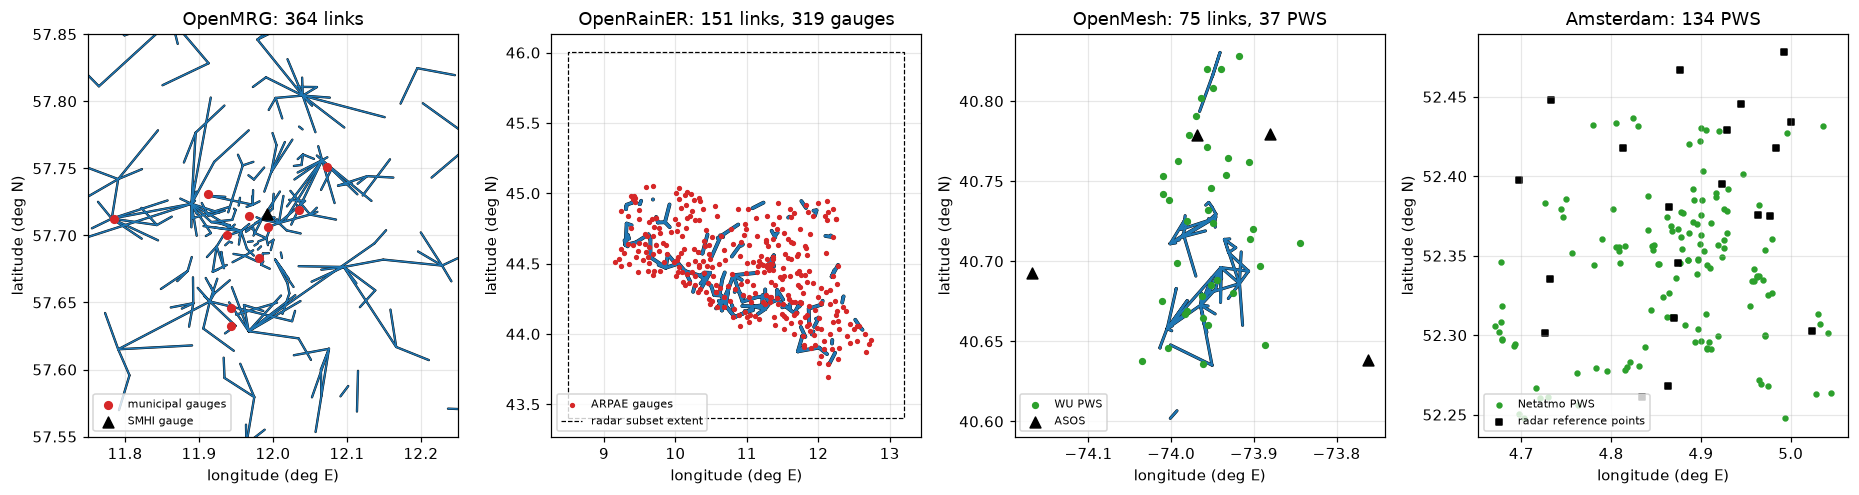

In [6]:
import poligrain as plg


def radar_box(ax, radar):
    lon, lat = radar.lon.values, radar.lat.values
    ax.plot([lon.min(), lon.max(), lon.max(), lon.min(), lon.min()],
            [lat.min(), lat.min(), lat.max(), lat.max(), lat.min()],
            "k--", lw=0.8, label="radar subset extent")


fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))

ax = axes[0]
d = loaded["OpenMRG"]
plg.plot_map.plot_lines(d["cml"].isel(sublink_id=0, time=0), ax=ax, line_color="C0", line_width=1)
ax.scatter(d["gauge_municipal"].lon, d["gauge_municipal"].lat, c="C3", s=25, label="municipal gauges", zorder=3)
ax.scatter(d["gauge_smhi"].lon, d["gauge_smhi"].lat, c="k", marker="^", s=50, label="SMHI gauge", zorder=3)
ax.set_xlim(11.75, 12.25); ax.set_ylim(57.55, 57.85)
ax.set_title(f"OpenMRG: {d['cml'].sizes['cml_id']} links")

ax = axes[1]
d = loaded["OpenRainER"]
plg.plot_map.plot_lines(d["cml"].isel(sublink_id=0, time=0), ax=ax, line_color="C0", line_width=2)
ax.scatter(d["gauge"].lon, d["gauge"].lat, c="C3", s=6, label="ARPAE gauges", zorder=3)
radar_box(ax, d["radar"])
ax.set_title(f"OpenRainER: {d['cml'].sizes['cml_id']} links, {d['gauge'].sizes['id']} gauges")

ax = axes[2]
d = loaded["OpenMesh"]
plg.plot_map.plot_lines(d["cml"].isel(sublink_id=0, time=0), ax=ax, line_color="C0", line_width=1.5)
ax.scatter(d["pws"].lon, d["pws"].lat, c="C2", s=14, label="WU PWS", zorder=3)
ax.scatter(d["asos"].lon, d["asos"].lat, c="k", marker="^", s=50, label="ASOS", zorder=3)
ax.set_title(f"OpenMesh: {d['cml'].sizes['cml_id']} links, {d['pws'].sizes['id']} PWS")

ax = axes[3]
d = loaded["Amsterdam PWS"]
ax.scatter(d["pws"].lon, d["pws"].lat, c="C2", s=10, label="Netatmo PWS")
ax.scatter(d["gauge"].lon, d["gauge"].lat, c="k", marker="s", s=20, label="radar reference points")
ax.set_title(f"Amsterdam: {d['pws'].sizes['id']} PWS")

for ax in axes:
    ax.set_xlabel("longitude (deg E)")
    ax.set_ylabel("latitude (deg N)")
    ax.legend(fontsize=7, loc="lower left")
plt.tight_layout()

The OpenMRG radar subset covers a ~70 x 90 km box around Gothenburg (not drawn: it is
larger than the panel). The networks differ in kind, not only in size: Gothenburg's
364 links are packed into one city, Emilia-Romagna's 151 are spread over a region of
300 km, and New York's community links are rooftop links on 5-69 GHz with received
power only. Path lengths, computed from the files:

In [7]:
lengths = pd.DataFrame({
    name: pd.Series(np.asarray(loaded[name]["cml"].length_km).ravel()).describe(percentiles=[0.5])
    for name in ["OpenMRG", "OpenRainER", "OpenMesh"]
}).loc[["count", "min", "50%", "max"]].round(2)
lengths.index = ["paths", "min length (km)", "median length (km)", "max length (km)"]
lengths

,OpenMRG,OpenRainER,OpenMesh
paths,364.00,151.00,75.00
min length (km),0.14,0.16,0.02
median length (km),2.27,6.34,1.45
max length (km),15.23,25.20,6.94


## 6. Time stamps: interval start or interval end?

An accumulation over 15 minutes can be stamped at the start of its interval or at the
end. The OpenSense convention (and most operational products) stamp the **end**: the
value at 12:15 is the rain that fell from 12:00 to 12:15. If one source is read as
interval-start and another as interval-end, every comparison is shifted by one step -
for convective rain that is enough to halve a correlation and to make the better
sensor look worse.

A practical check is to correlate two sources at a few lags. Here: the OpenRainER
radar (15-min, stamped at interval end) sampled at the grid cell of each ARPAE gauge,
against the gauges (also stamped at end), during the stormy days of the subset.

radar shifted by (steps of 15 min),-3,-2,-1,0,1,2,3
correlation with gauges,0.165,0.215,0.364,0.755,0.549,0.27,0.182


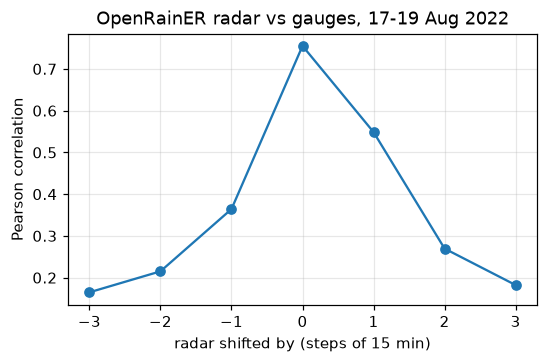

In [8]:
d = loaded["OpenRainER"]
gauges = d["gauge"].R                               # mm/h, (time, id)
at_gauges = plg.spatial.GridAtPoints(
    da_gridded_data=d["radar"].R.isel(time=0), da_point_data=gauges.isel(time=0),
    nnear=1, stat="best", use_lon_lat=True,
)(da_gridded_data=d["radar"].R, da_point_data=gauges.transpose("id", "time"))
window = slice("2022-08-17", "2022-08-19")
g = gauges.sel(time=window).transpose("id", "time")
r = at_gauges.sel(time=window).transpose("id", "time")

rows = []
for lag in range(-3, 4):
    shifted = r.shift(time=lag)
    ok = np.isfinite(g.values) & np.isfinite(shifted.values)
    rows.append({"radar shifted by (steps of 15 min)": lag,
                 "correlation with gauges": np.corrcoef(g.values[ok], shifted.values[ok])[0, 1]})
lags = pd.DataFrame(rows).set_index("radar shifted by (steps of 15 min)")
ax = lags.plot(marker="o", legend=False, figsize=(5.5, 3.2))
ax.set_ylabel("Pearson correlation")
ax.set_title("OpenRainER radar vs gauges, 17-19 Aug 2022")
lags.round(3).T

The correlation peaks at lag 0, so both products follow the same convention. A peak at
+1 or -1 would mean one of them is stamped at the other end of its interval.
`core.opensense.networks.LABELS` records the convention of every source FieldSense
reads, each established by lagging it against the 1-minute link signal; all hourly
products in the projects are converted to **hour-ending** time.

When you resample yourself, say which end you mean. pandas and xarray default to
`label="left", closed="left"` - right for start-stamped data, wrong for end-stamped
data. A toy series of 15-min accumulations stamped at interval end makes the
difference visible: 1 mm fell in each quarter hour from 00:00 to 01:00, then 10 mm in
the quarter hour ending 01:15.

In [9]:
toy = xr.DataArray([1.0, 1.0, 1.0, 1.0, 10.0], dims="time",
                   coords={"time": pd.date_range("2022-08-17 00:15", periods=5, freq="15min")})
pd.DataFrame({
    "hour-ending (label/closed right)": toy.resample(time="1h", label="right", closed="right").sum().to_series(),
    "pandas default (left/left)": toy.resample(time="1h").sum().to_series(),
}).fillna(0)

/var/folders/9q/vrtjr2_56sjdhy0yx86b5bjr0000gn/T/ipykernel_34104/498421585.py:1: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  toy = xr.DataArray([1.0, 1.0, 1.0, 1.0, 10.0], dims="time",


,hour-ending (label/closed right),pandas default (left/left)
time,,
2022-08-17 00:00:00,0.0,3.0
2022-08-17 01:00:00,4.0,11.0
2022-08-17 02:00:00,10.0,0.0


Read correctly, the hour 00:00-01:00 had 4 mm and the next hour 10 mm (first column).
With the default, the hour labelled 00:00 gets 3 mm and the hour labelled 01:00 gets
11 mm: the quarter hour ending at 01:00 has been moved into the following hour, and
every total is labelled one hour early.

## 7. The full records

The example subsets are for learning and testing, **never a basis for a result**. The
projects read the full records, looked up in two places by
[`core/data_paths.py`](../core/data_paths.py) - the only file in the repository that
writes an input path down:

1. `data/interim/` inside the repository - a local, git-ignored override;
2. `~/data/cml/` - the shared data store (set `CML_DATA_ROOT` to move it).

[`DATA.md`](../DATA.md) lists every file, what it is and which code reads it. The
fetchers download the published archives and check their size and checksum:

```bash
python -m core.opensense.fetch --dataset openmrg        # 318 MB zip (4.6 GB unpacked)
python -m core.opensense.fetch --dataset openrainer     # monthly archives, ~4.6 GB
python -m core.opensense.fetch --dataset openmesh       # links
python -m core.opensense.fetch --dataset openmesh_pws   # Weather Underground PWS
python -m core.opensense.fetch --dataset openmrg2_pws   # Gothenburg Netatmo PWS
```

Once downloaded, `core.opensense.networks` gives the three city networks one interface
- `links(start, end)`, `points(start, end)` and `radar_hourly(start, end)` - which is
what the multi-network projects use. Which files are present on this machine:

In [10]:
from pathlib import Path

from core import data_paths as dp

for label, rel in [("OpenMRG links", dp.OPENMRG_CML), ("OpenMRG radar", dp.OPENMRG_RADAR),
                   ("OpenMRG2 PWS", dp.OPENMRG2), ("OpenRainER links", dp.OPENRAINER_MONTHLY["CML"]),
                   ("OpenMesh release", dp.OPENMESH_RELEASE)]:
    p = dp.data_path(rel)
    shown = str(p).replace(str(Path.home()), "~")
    print(f"{label:17s} {'present' if p.exists() else 'not downloaded':15s} {shown}")

OpenMRG links     present         ~/data/cml/openmrg/cml/openmrg_cml_full.nc
OpenMRG radar     present         ~/data/cml/openmrg/weather/openmrg_radar_full.nc
OpenMRG2 PWS      present         ~/data/cml/openmrg2/weather
OpenRainER links  present         ~/data/cml/openrainer/cml
OpenMesh release  present         ~/data/cml/openmesh/release_v1


OpenMRG2's Netatmo stations are not part of the example subsets. If they are present,
`core.opensense.openmrg2.load` opens them in the same format (pass `fetch_missing=True`
to download them):

In [11]:
from core.opensense import openmrg2

try:
    pws = openmrg2.load(fetch_missing=False)["pws"]
    print(f"OpenMRG2: {pws.sizes['id']} PWS, {pd.Timestamp(pws.time.values[0]):%Y-%m-%d} "
          f"to {pd.Timestamp(pws.time.values[-1]):%Y-%m-%d}")
except (FileNotFoundError, OSError) as exc:
    print("OpenMRG2 not downloaded on this machine:", type(exc).__name__)

OpenMRG2: 30 PWS, 2015-06-01 to 2015-09-01


**Next:** [Tutorial 2](02_cml_signal_to_rain.ipynb) turns the signal levels of one
OpenMRG link into a rain rate, step by step.

## 8. References and links

* Andersson, J. C. M., Olsson, J., van de Beek, R., and Hansryd, J. (2022). OpenMRG: Open data from Microwave links, Radar, and Gauges for rainfall quantification in Gothenburg, Sweden. *Earth Syst. Sci. Data*, 14, 5411-5426. [doi:10.5194/essd-14-5411-2022](https://doi.org/10.5194/essd-14-5411-2022)
* Chwala, C., and Kunstmann, H. (2019). Commercial microwave link networks for rainfall observation: Assessment of the current status and future challenges. *WIREs Water*, 6, e1337. [doi:10.1002/wat2.1337](https://doi.org/10.1002/wat2.1337)
* Covi, E., and Roversi, G. OpenRainER dataset. Zenodo. [doi:10.5281/zenodo.10593848](https://doi.org/10.5281/zenodo.10593848)
* de Vos, L. W., Leijnse, H., Overeem, A., and Uijlenhoet, R. (2019). Quality control for crowdsourced personal weather stations to enable operational rainfall monitoring. *Geophys. Res. Lett.*, 46, 8820-8829. [doi:10.1029/2019GL083731](https://doi.org/10.1029/2019GL083731)
* Fencl, M., et al. (2023). Data formats and standards for opportunistic rainfall sensors. *Open Research Europe*, 3, 169. [doi:10.12688/openreseurope.16068.2](https://doi.org/10.12688/openreseurope.16068.2)
* Jacoby, D., et al. (2026). OpenMesh: wireless signal dataset for opportunistic urban weather sensing in New York City. *Earth Syst. Sci. Data*, 18, 5817-5836. [doi:10.5194/essd-18-5817-2026](https://doi.org/10.5194/essd-18-5817-2026)
* Messer, H., Zinevich, A., and Alpert, P. (2006). Environmental monitoring by wireless communication networks. *Science*, 312, 713. [doi:10.1126/science.1120034](https://doi.org/10.1126/science.1120034)
* Overeem, A., Leijnse, H., and Uijlenhoet, R. (2013). Country-wide rainfall maps from cellular communication networks. *PNAS*, 110, 2741-2745. [doi:10.1073/pnas.1217961110](https://doi.org/10.1073/pnas.1217961110)
* OpenSense COST Action CA20136: [opensenseaction.eu](https://opensenseaction.eu), [cost.eu/actions/CA20136](https://www.cost.eu/actions/CA20136/)
* Software: [poligrain](https://poligrain.readthedocs.io), [pycomlink](https://github.com/pycomlink/pycomlink), [opensense_example_data](https://github.com/OpenSenseAction/opensense_example_data), [OS_data_format_conventions](https://github.com/OpenSenseAction/OS_data_format_conventions)